# Data Preprocessing

## Importing Libraries

In [1]:
import numpy as np
import math
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Defining Functions

In [2]:
#https://towardsdatascience.com/using-scikit-learns-binary-trees-to-efficiently-find-latitude-and-longitude-neighbors-909979bd929b
# Creates new columns converting coordinate degrees to radians.
def add_coordinates_in_radians(df_geolocations,lat,lon):
    """
    It gets a dataframe which has at least two columns, one for latitude, one for longitude, 
    and the name of the column related to latitude and the name of the column related to longitude.
    It returns the same dataframe with two columns added one for latitude in radians (lat+"_rad")
    and one for longitude in radians (lon+"_rad")
    """
    for column in df_geolocations[[lat, lon]]:
        rad = np.deg2rad(df_geolocations[column].values)
        df_geolocations[f'{column}_rad'] = rad
    return df_geolocations


## Loading neighborhood dataset

Neighborhood dataset CSV file was downloade on 22 August 2022 from:

https://data.baltimorecity.gov/datasets/neighborhood-1/explore?location=39.284818%2C-76.620500%2C11.47&showTable=true

In [3]:
df_neighood = pd.read_csv('Data Frames/Originals/Neighborhoods.csv',low_memory=False)
display(df_neighood.head(5))

,fid,color_2,Name,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,...,hh_chng,avehhsize,created_us,created_da,last_edite,last_edi_1,shape_star,shape_stle,SHAPE__Length,SHAPE__Area
0,1,2,Abell,889.0,606.0,213.0,3.0,33.0,1,4.0,...,-45.0,2.02045,,NaN,,NaN,2.034706e+06,5892.827778,2324.674182,3.163361e+05
1,2,2,Allendale,3554.0,18.0,3497.0,8.0,6.0,0,5.0,...,-11.0,2.47244,,NaN,,NaN,1.132664e+07,14276.845230,5624.634685,1.759173e+06
2,3,2,Arcadia,1235.0,623.0,537.0,4.0,12.0,0,10.0,...,-8.0,2.67316,,NaN,,NaN,6.302177e+06,12268.078900,4839.572646,9.800179e+05
3,4,5,Arlington,2598.0,33.0,2496.0,3.0,9.0,0,10.0,...,-126.0,2.38369,,NaN,,NaN,5.034869e+06,9756.115594,3846.599506,7.832708e+05
4,5,2,Armistead Gardens,3458.0,2698.0,108.0,51.0,14.0,8,413.0,...,176.0,2.37012,,NaN,,NaN,1.318063e+07,16915.744130,6667.429263,2.048122e+06


In [4]:
print(df_neighood[df_neighood['SHAPE__Area'].isna()])

Empty DataFrame
Columns: [fid, color_2, Name, Population, White, Blk_AfAm, AmInd_AkNa, Asian, NatHaw_Pac, Other_Race, TwoOrMore, Hisp_Lat, Male, Female, age0_4, age5_11, age12_14, age15_17, age18_24, age25_34, age35_44, age45_64, age65ovr, families, married, married18, malehh, malehh18, femalehh, femalehh18, housing, occupied, occ_own, occ_rent, vacant, vac_rent, vac_sale, vac_other, geodata_eg, pop_dens, pop_chng, hh_chng, avehhsize, created_us, created_da, last_edite, last_edi_1, shape_star, shape_stle, SHAPE__Length, SHAPE__Area]
Index: []

[0 rows x 51 columns]


## fixing up neighborhood dataframe

Step 1: Removing the extra columns from the DF.</br>
Step 2: Adding the needed columns (Those whose value is calculated using other columns).</br>
Step 3: Removing rows without a neighborhood-name</br>
Step 4: Sorting the rows based on neighborhood-name</br>
Step 5: Changing neighborhood-names to all capital letters</br>
Step 6: Removing the neighborhoods with no residents</br>



In [5]:
noResidents=[]
df_neighood=df_neighood[['Name', 'Population', 'White', 'Blk_AfAm', 'AmInd_AkNa',
       'Asian', 'NatHaw_Pac', 'Other_Race', 'TwoOrMore', 'Hisp_Lat','SHAPE__Area']]

df_neighood['TotalNumberOfResidents'] = ""
df_neighood['AllRaceExcptBlk'] = ""
df_neighood['IsBlack'] = False
df_neighood['IsWhite'] = False

#Checking for nulls and removing them
df_neighood= df_neighood[df_neighood.Name.notna()]

df_neighood = df_neighood.sort_values(by = ['Name'])
df_neighood['Name']= df_neighood['Name'].apply(lambda x: x.upper())


#print("Places with no residents (park, cemetry, factory,...):")
for nIndex,nRow in df_neighood.iterrows():
    t = nRow['White']+ nRow['AmInd_AkNa']+ nRow['Asian']+ nRow['NatHaw_Pac']+ nRow['Other_Race']+nRow['Hisp_Lat']+ nRow['Blk_AfAm']
    tExceptB= t-nRow['Blk_AfAm']
    df_neighood.at[nIndex,'AllRaceExcptBlk']= tExceptB
    df_neighood.at[nIndex,'TotalNumberOfResidents']= t
    b= nRow['Blk_AfAm']
    w= nRow['White']
    o= t- (b+w)
    m= max(b, w, o)
    if t == 0 :
        noResidents.append(nRow['Name'])
        print("no res: ",nRow['Name'])
        df_neighood= df_neighood.drop(nIndex, axis=0)
    elif (((m==b)+(m==w)+(m==o))>1):
        print("no majority: ",nRow['Name'])
        
    elif b == m:
        df_neighood.at[nIndex,'IsBlack']= True
    elif w == m:
        df_neighood.at[nIndex,'IsWhite']= True


no res:  CANTON INDUSTRIAL AREA
no res:  CARROLL - CAMDEN INDUSTRIAL AREA
no res:  CARROLL PARK
no res:  CLIFTON PARK
no res:  CURTIS BAY INDUSTRIAL AREA
no res:  DRUID HILL PARK
no res:  DUNDALK MARINE TERMINAL
no res:  GREENMOUNT CEMETERY
no res:  GWYNNS FALLS/LEAKIN PARK
no res:  HAWKINS POINT
no res:  HERRING RUN PARK
no res:  HOLABIRD INDUSTRIAL PARK
no res:  JONES FALLS AREA
no res:  LOWER HERRING RUN PARK
no res:  MIDDLE BRANCH/REEDBIRD PARKS
no res:  MT PLEASANT PARK
no res:  ORANGEVILLE INDUSTRIAL AREA
no res:  PATTERSON PARK
no res:  PORT COVINGTON
no res:  SETON BUSINESS PARK
no res:  SPRING GARDEN INDUSTRIAL AREA
no res:  STADIUM AREA


In [6]:
print(noResidents)

['CANTON INDUSTRIAL AREA', 'CARROLL - CAMDEN INDUSTRIAL AREA', 'CARROLL PARK', 'CLIFTON PARK', 'CURTIS BAY INDUSTRIAL AREA', 'DRUID HILL PARK', 'DUNDALK MARINE TERMINAL', 'GREENMOUNT CEMETERY', 'GWYNNS FALLS/LEAKIN PARK', 'HAWKINS POINT', 'HERRING RUN PARK', 'HOLABIRD INDUSTRIAL PARK', 'JONES FALLS AREA', 'LOWER HERRING RUN PARK', 'MIDDLE BRANCH/REEDBIRD PARKS', 'MT PLEASANT PARK', 'ORANGEVILLE INDUSTRIAL AREA', 'PATTERSON PARK', 'PORT COVINGTON', 'SETON BUSINESS PARK', 'SPRING GARDEN INDUSTRIAL AREA', 'STADIUM AREA']


In [7]:
print(df_neighood.head(2))

        Name  Population  White  Blk_AfAm  AmInd_AkNa  Asian  NatHaw_Pac  \
0      ABELL       889.0  606.0     213.0         3.0   33.0           1   
1  ALLENDALE      3554.0   18.0    3497.0         8.0    6.0           0   

   Other_Race  TwoOrMore  Hisp_Lat   SHAPE__Area TotalNumberOfResidents  \
0         4.0       29.0      30.0  3.163361e+05                  890.0   
1         5.0       20.0      21.0  1.759173e+06                 3555.0   

  AllRaceExcptBlk  IsBlack  IsWhite  
0           677.0    False     True  
1            58.0     True    False  


In [8]:
"""print(len(df_Crime[df_Crime['Neighborhood']=='DUNBAR'])) -> 0
print(len(df_Crime[df_Crime['Neighborhood']=='BROADWAY EAST'])) -> 5000"""

"print(len(df_Crime[df_Crime['Neighborhood']=='DUNBAR'])) -> 0\nprint(len(df_Crime[df_Crime['Neighborhood']=='BROADWAY EAST'])) -> 5000"

## Matching neighborhoods'name between the datasets
Some of the neighborhoods names are different in the crime dataset and also the kml file of the neighborhood boundaries, so we are changing those neighborhood's names in the neighborhood dataset

In [9]:
df_neighood[df_neighood['Name']=='STADIUM AREA']

,Name,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,TwoOrMore,Hisp_Lat,SHAPE__Area,TotalNumberOfResidents,AllRaceExcptBlk,IsBlack,IsWhite


In [10]:
df_neighood[df_neighood['Name']=='BOYD-BOOTH']

,Name,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,TwoOrMore,Hisp_Lat,SHAPE__Area,TotalNumberOfResidents,AllRaceExcptBlk,IsBlack,IsWhite


In [11]:
name1=['BUTCHERS HILL','BOOTH-BOYD','CHINQUAPIN PARK - BELVEDERE','MIDTOWN EDMONDSON',
       'FAIRFIELD','MADISON EASTEND','MILL HILL',"ODONNELL HEIGHTS",'WASHINGTON VILLAGE',
      'DUNBAR']
name2=["BUTCHER'S HILL",'BOYD-BOOTH','CHINQUAPIN PARK', 'MIDTOWN-EDMONDSON','FAIRFIELD AREA',
      'MADISON-EASTEND','MILLHILL',"O'DONNELL HEIGHTS", 'WASHINGTON VILLAGE/PIGTOWN','DUNBAR-BROADWAY']
for i in range(0,len(name1)):
    try: 
        ind= df_neighood[df_neighood['Name']==name1[i]].index[0]
        df_neighood.at[ind, 'Name']= name2[i]
    except:
        print(name1[i])

## Adding neighborhood boundaries to the dataset

reading KML file code is gotten from: 

https://gis.stackexchange.com/questions/443226/extracting-multiple-elements-from-within-the-name-tag-in-kml


The KLM file that has neighborhood boundaries was downloaded on 15 March 2023 from:

https://data.baltimorecity.gov/datasets/baltimore::neighborhood-1/explore?location=39.284823%2C-76.620500%2C11.51 

In [12]:
import xml.etree.ElementTree as ET
import re

# KML parse
tree = ET.parse('Data Frames/Originals/Neighborhood.kml')
root = tree.getroot()

# Identify default namespace
namespace = re.match('\{(.*?)\}kml', root.tag).group(1)
ns = {'def': namespace}

# Define coordinates RegEx
coord_ex = '(-?\d+\.\d+),'
coord_ey = '(-?\d+\.\d+)'
heig_ex = '(\d+)'
regex = coord_ex + coord_ey

# Find coordinates
for i in root.findall('.//def:Placemark', ns):
    name = i.find('def:name', ns).text.upper()
    coord = i.find('.//def:coordinates', ns)   
    if not coord is None:
        coord = coord.text.strip()
        coord = re.findall(regex, coord)
        pin = 0
        poly="POLYGON (("
        #(long, lat, heig)
        for lat,long  in coord:
            if(pin==len(coord)-1):
                poly= poly+ lat+ " "+ long+ "))"
            else:
                poly= poly+ lat+ " "+ long+ ","
            pin += 1
        try:
            ind= df_neighood[df_neighood['Name']==name].index[0]
        except:
            print(name)
                
        df_neighood.at[ind, 'Boundaries']=poly
            
display(df_neighood.head(5))
print(df_neighood[df_neighood['Boundaries'].isna()])

CANTON INDUSTRIAL AREA
CARROLL - CAMDEN INDUSTRIAL AREA
CARROLL PARK
CLIFTON PARK
CURTIS BAY INDUSTRIAL AREA
DRUID HILL PARK
DUNDALK MARINE TERMINAL
GREENMOUNT CEMETERY
GWYNNS FALLS/LEAKIN PARK
HAWKINS POINT
HERRING RUN PARK
HOLABIRD INDUSTRIAL PARK
JONES FALLS AREA
LOWER HERRING RUN PARK
MIDDLE BRANCH/REEDBIRD PARKS
MT PLEASANT PARK
ORANGEVILLE INDUSTRIAL AREA
PATTERSON PARK
PORT COVINGTON
SETON BUSINESS PARK
SPRING GARDEN INDUSTRIAL AREA
STADIUM AREA


,Name,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,TwoOrMore,Hisp_Lat,SHAPE__Area,TotalNumberOfResidents,AllRaceExcptBlk,IsBlack,IsWhite,Boundaries
0,ABELL,889.0,606.0,213.0,3.0,33.0,1,4.0,29.0,30.0,3.163361e+05,890.0,677.0,False,True,"POLYGON ((-76.6111324007745 39.3234461864839,-..."
1,ALLENDALE,3554.0,18.0,3497.0,8.0,6.0,0,5.0,20.0,21.0,1.759173e+06,3555.0,58.0,True,False,"POLYGON ((-76.672627345299 39.2918441815671,-7..."
2,ARCADIA,1235.0,623.0,537.0,4.0,12.0,0,10.0,49.0,31.0,9.800179e+05,1217.0,680.0,False,True,"POLYGON ((-76.5685271368632 39.335951205063,-7..."
3,ARLINGTON,2598.0,33.0,2496.0,3.0,9.0,0,10.0,47.0,17.0,7.832708e+05,2568.0,72.0,True,False,"POLYGON ((-76.6862655982037 39.3479128201721,-..."
4,ARMISTEAD GARDENS,3458.0,2698.0,108.0,51.0,14.0,8,413.0,166.0,841.0,2.048122e+06,4133.0,4025.0,False,True,"POLYGON ((-76.5588020984783 39.3064645435754,-..."


Empty DataFrame
Columns: [Name, Population, White, Blk_AfAm, AmInd_AkNa, Asian, NatHaw_Pac, Other_Race, TwoOrMore, Hisp_Lat, SHAPE__Area, TotalNumberOfResidents, AllRaceExcptBlk, IsBlack, IsWhite, Boundaries]
Index: []


In [13]:
df_neighood.to_csv('Data Frames/Preprocessed/Neighborhoods_Residential.csv', index=False)
df_neighood=pd.read_csv('Data Frames/Preprocessed/Neighborhoods_Residential.csv')
df_neighood.head()

,Name,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,TwoOrMore,Hisp_Lat,SHAPE__Area,TotalNumberOfResidents,AllRaceExcptBlk,IsBlack,IsWhite,Boundaries
0,ABELL,889.0,606.0,213.0,3.0,33.0,1,4.0,29.0,30.0,3.163361e+05,890.0,677.0,False,True,"POLYGON ((-76.6111324007745 39.3234461864839,-..."
1,ALLENDALE,3554.0,18.0,3497.0,8.0,6.0,0,5.0,20.0,21.0,1.759173e+06,3555.0,58.0,True,False,"POLYGON ((-76.672627345299 39.2918441815671,-7..."
2,ARCADIA,1235.0,623.0,537.0,4.0,12.0,0,10.0,49.0,31.0,9.800179e+05,1217.0,680.0,False,True,"POLYGON ((-76.5685271368632 39.335951205063,-7..."
3,ARLINGTON,2598.0,33.0,2496.0,3.0,9.0,0,10.0,47.0,17.0,7.832708e+05,2568.0,72.0,True,False,"POLYGON ((-76.6862655982037 39.3479128201721,-..."
4,ARMISTEAD GARDENS,3458.0,2698.0,108.0,51.0,14.0,8,413.0,166.0,841.0,2.048122e+06,4133.0,4025.0,False,True,"POLYGON ((-76.5588020984783 39.3064645435754,-..."


## Loading Crime Dataset

Crime dataset csv file was downloaded on 11 March 2023 from:

https://data.baltimorecity.gov/datasets/baltimore::part-1-crime-data/explore?location=18.619939%2C-38.355639%2C4.62&showTable=true 

In [14]:
df_Crime = pd.read_csv(filepath_or_buffer='Data Frames/Originals/Crime_Data.csv', low_memory=False)
display(df_Crime.head(5))

,X,Y,ccno,crimedatetime,crimecode,location,description,inside_outside,weapon,post,...,ethnicity,district,neighborhood,latitude,longitude,geolocation,premise,total_incidents,objectid,shape
0,-76.618212,39.293193,23B08103,2023/02/25 11:20:00+00,4E,300 PARK AVE,COMMON ASSAULT,NaN,PERSONAL_WEAPONS,114,...,NaN,CENTRAL,Downtown,39.293193,-76.618212,"(39.293193,-76.618212)",NaN,1,1,NaN
1,-76.606045,39.311660,23B08000,2023/02/25 01:46:00+00,4E,900 E NORTH AVE,COMMON ASSAULT,NaN,NaN,312,...,NaN,EASTERN,East Baltimore Midway,39.311660,-76.606045,"(39.31166,-76.606045)",NaN,1,2,NaN
2,-76.572146,39.296252,23B08008,2023/02/25 02:35:00+00,4E,400 N EAST AVE,COMMON ASSAULT,NaN,PERSONAL_WEAPONS,224,...,NaN,SOUTHEAST,Ellwood Park/Monument,39.296252,-76.572146,"(39.296252,-76.572146)",NaN,1,3,NaN
3,-76.610023,39.289875,23B08010,2023/02/25 02:44:00+00,4E,400 E BALTIMORE ST,COMMON ASSAULT,NaN,NaN,111,...,NOT_HISPANIC_OR_LATINO,CENTRAL,DOWNTOWN,39.289875,-76.610023,"(39.289875155250655,-76.610022671112318)",NaN,1,4,NaN
4,-76.621772,39.249538,23B08027,2023/02/25 03:52:00+00,5A,600 BRIDGEVIEW RD,BURGLARY,NaN,NaN,922,...,NOT_HISPANIC_OR_LATINO,SOUTHERN,Cherry Hill,39.249538,-76.621772,"(39.249538,-76.621772)",NaN,1,5,NaN


## fixing up Crime data

In [15]:
df_Crime.rename(columns = {'crimedatetime':'CrimeDateTime', 'latitude':'Latitude','longitude':'Longitude','neighborhood':'Neighborhood'}, inplace = True)
df_Crime= df_Crime[df_Crime.Latitude != 0]
df_Crime= df_Crime[df_Crime.Longitude != 0]
df_Crime= df_Crime[df_Crime.Neighborhood.notna()]
df_Crime['Neighborhood']= df_Crime['Neighborhood'].apply(lambda x: x.upper())
display(df_Crime.head(5))

,X,Y,ccno,CrimeDateTime,crimecode,location,description,inside_outside,weapon,post,...,ethnicity,district,Neighborhood,Latitude,Longitude,geolocation,premise,total_incidents,objectid,shape
0,-76.618212,39.293193,23B08103,2023/02/25 11:20:00+00,4E,300 PARK AVE,COMMON ASSAULT,NaN,PERSONAL_WEAPONS,114,...,NaN,CENTRAL,DOWNTOWN,39.293193,-76.618212,"(39.293193,-76.618212)",NaN,1,1,NaN
1,-76.606045,39.311660,23B08000,2023/02/25 01:46:00+00,4E,900 E NORTH AVE,COMMON ASSAULT,NaN,NaN,312,...,NaN,EASTERN,EAST BALTIMORE MIDWAY,39.311660,-76.606045,"(39.31166,-76.606045)",NaN,1,2,NaN
2,-76.572146,39.296252,23B08008,2023/02/25 02:35:00+00,4E,400 N EAST AVE,COMMON ASSAULT,NaN,PERSONAL_WEAPONS,224,...,NaN,SOUTHEAST,ELLWOOD PARK/MONUMENT,39.296252,-76.572146,"(39.296252,-76.572146)",NaN,1,3,NaN
3,-76.610023,39.289875,23B08010,2023/02/25 02:44:00+00,4E,400 E BALTIMORE ST,COMMON ASSAULT,NaN,NaN,111,...,NOT_HISPANIC_OR_LATINO,CENTRAL,DOWNTOWN,39.289875,-76.610023,"(39.289875155250655,-76.610022671112318)",NaN,1,4,NaN
4,-76.621772,39.249538,23B08027,2023/02/25 03:52:00+00,5A,600 BRIDGEVIEW RD,BURGLARY,NaN,NaN,922,...,NOT_HISPANIC_OR_LATINO,SOUTHERN,CHERRY HILL,39.249538,-76.621772,"(39.249538,-76.621772)",NaN,1,5,NaN


## Droping the crimes whose neighborhoods are not known

The code below can be commented out because there seems to be no more crimes with neighborhoods that can't be found in the neighborhood dataset. but because we might download a new crime dataset or new neighborhood dataset, we might get new neighborhood name conflicts, so we are keeping it.

In [16]:
from tqdm.notebook import tqdm, trange
import time 
unknown= set({})
with tqdm(total=len(df_Crime)) as pbar:
    for crimeIndex,crimeRow in df_Crime.iterrows(): 
        crimeRow['Neighborhood']
        N= df_neighood[df_neighood['Name'] ==crimeRow['Neighborhood']]
        if N.empty:
            unknown.add(crimeRow['Neighborhood'])
            df_Crime.drop([crimeIndex], axis=0, inplace=True) 
        pbar.update()

print("Unknown Neighborhoods:")
print(unknown)

  0%|          | 0/539766 [00:00<?, ?it/s]

Unknown Neighborhoods:
{'LOWER HERRING RUN PARK', 'ORANGEVILLE INDUSTRIAL AREA', 'HAWKINS POINT', 'GWYNNS FALLS/LEAKIN PARK', 'SPRING GARDEN INDUSTRIAL AREA', 'MIDDLE BRANCH/REEDBIRD PARKS', 'PATTERSON PARK', 'CLIFTON PARK', 'GREENMOUNT CEMETERY', 'HOLABIRD INDUSTRIAL PARK', 'CARROLL PARK', 'CANTON INDUSTRIAL AREA', 'STADIUM AREA', 'HERRING RUN PARK', 'PORT COVINGTON', 'DUNDALK MARINE TERMINAL', 'JONES FALLS AREA', 'DRUID HILL PARK', 'MT PLEASANT PARK', 'CURTIS BAY INDUSTRIAL AREA', 'CARROLL - CAMDEN INDUSTRIAL AREA', 'SETON BUSINESS PARK'}


In [17]:
df_Crime= add_coordinates_in_radians(df_Crime,"Latitude","Longitude") 

#Formating CrimeDate to specific format
df_Crime['CrimeDateTime'] =  pd.to_datetime(df_Crime['CrimeDateTime'], format='%Y/%m/%d %H:%M:%S+00', errors = 'coerce')

df_Crime['date'] = pd.DatetimeIndex(df_Crime['CrimeDateTime']).date
df_Crime= df_Crime[df_Crime.date.notna()]
df_Crime['year'] = pd.DatetimeIndex(df_Crime['CrimeDateTime']).year
df_Crime= df_Crime[df_Crime.year.notna()]
df_Crime['year'] = df_Crime['year'].astype(int)
df_Crime['month'] = pd.DatetimeIndex(df_Crime['CrimeDateTime']).month
df_Crime= df_Crime[df_Crime.month.notna()]
df_Crime['month'] = df_Crime['month'].astype(int)
df_Crime['day'] = pd.DatetimeIndex(df_Crime['CrimeDateTime']).day
df_Crime= df_Crime[df_Crime.day.notna()]
df_Crime['day'] = df_Crime['day'].astype(int)
    
df_Crime.reset_index(drop=True)
display(df_Crime.head(5))

,X,Y,ccno,CrimeDateTime,crimecode,location,description,inside_outside,weapon,post,...,premise,total_incidents,objectid,shape,Latitude_rad,Longitude_rad,date,year,month,day
0,-76.618212,39.293193,23B08103,2023-02-25 11:20:00,4E,300 PARK AVE,COMMON ASSAULT,NaN,PERSONAL_WEAPONS,114,...,NaN,1,1,NaN,0.685796,-1.337240,2023-02-25,2023,2,25
1,-76.606045,39.311660,23B08000,2023-02-25 01:46:00,4E,900 E NORTH AVE,COMMON ASSAULT,NaN,NaN,312,...,NaN,1,2,NaN,0.686118,-1.337028,2023-02-25,2023,2,25
2,-76.572146,39.296252,23B08008,2023-02-25 02:35:00,4E,400 N EAST AVE,COMMON ASSAULT,NaN,PERSONAL_WEAPONS,224,...,NaN,1,3,NaN,0.685849,-1.336436,2023-02-25,2023,2,25
3,-76.610023,39.289875,23B08010,2023-02-25 02:44:00,4E,400 E BALTIMORE ST,COMMON ASSAULT,NaN,NaN,111,...,NaN,1,4,NaN,0.685738,-1.337097,2023-02-25,2023,2,25
4,-76.621772,39.249538,23B08027,2023-02-25 03:52:00,5A,600 BRIDGEVIEW RD,BURGLARY,NaN,NaN,922,...,NaN,1,5,NaN,0.685034,-1.337302,2023-02-25,2023,2,25


In [18]:
df_neighood = df_neighood.set_index('Name', drop=True)
display(df_neighood.head(5))

,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,TwoOrMore,Hisp_Lat,SHAPE__Area,TotalNumberOfResidents,AllRaceExcptBlk,IsBlack,IsWhite,Boundaries
Name,,,,,,,,,,,,,,,
ABELL,889.0,606.0,213.0,3.0,33.0,1,4.0,29.0,30.0,3.163361e+05,890.0,677.0,False,True,"POLYGON ((-76.6111324007745 39.3234461864839,-..."
ALLENDALE,3554.0,18.0,3497.0,8.0,6.0,0,5.0,20.0,21.0,1.759173e+06,3555.0,58.0,True,False,"POLYGON ((-76.672627345299 39.2918441815671,-7..."
ARCADIA,1235.0,623.0,537.0,4.0,12.0,0,10.0,49.0,31.0,9.800179e+05,1217.0,680.0,False,True,"POLYGON ((-76.5685271368632 39.335951205063,-7..."
ARLINGTON,2598.0,33.0,2496.0,3.0,9.0,0,10.0,47.0,17.0,7.832708e+05,2568.0,72.0,True,False,"POLYGON ((-76.6862655982037 39.3479128201721,-..."
ARMISTEAD GARDENS,3458.0,2698.0,108.0,51.0,14.0,8,413.0,166.0,841.0,2.048122e+06,4133.0,4025.0,False,True,"POLYGON ((-76.5588020984783 39.3064645435754,-..."


In [19]:
print(df_neighood.loc['ABELL'])

Population                                                            889.0
White                                                                 606.0
Blk_AfAm                                                              213.0
AmInd_AkNa                                                              3.0
Asian                                                                  33.0
NatHaw_Pac                                                                1
Other_Race                                                              4.0
TwoOrMore                                                              29.0
Hisp_Lat                                                               30.0
SHAPE__Area                                                     316336.0625
TotalNumberOfResidents                                                890.0
AllRaceExcptBlk                                                       677.0
IsBlack                                                               False
IsWhite     

In [20]:
neighood_race= df_neighood[['IsBlack', 'IsWhite']]
df_Crime= df_Crime.join(neighood_race, on='Neighborhood')
df_Crime= df_Crime[['CrimeDateTime','date','year','month','day','crimecode','description','Latitude','Longitude','Latitude_rad','Longitude_rad','Neighborhood','IsBlack', 'IsWhite']]
df_Crime.head()

,CrimeDateTime,date,year,month,day,crimecode,description,Latitude,Longitude,Latitude_rad,Longitude_rad,Neighborhood,IsBlack,IsWhite
0,2023-02-25 11:20:00,2023-02-25,2023,2,25,4E,COMMON ASSAULT,39.293193,-76.618212,0.685796,-1.337240,DOWNTOWN,False,True
1,2023-02-25 01:46:00,2023-02-25,2023,2,25,4E,COMMON ASSAULT,39.311660,-76.606045,0.686118,-1.337028,EAST BALTIMORE MIDWAY,True,False
2,2023-02-25 02:35:00,2023-02-25,2023,2,25,4E,COMMON ASSAULT,39.296252,-76.572146,0.685849,-1.336436,ELLWOOD PARK/MONUMENT,True,False
3,2023-02-25 02:44:00,2023-02-25,2023,2,25,4E,COMMON ASSAULT,39.289875,-76.610023,0.685738,-1.337097,DOWNTOWN,False,True
4,2023-02-25 03:52:00,2023-02-25,2023,2,25,5A,BURGLARY,39.249538,-76.621772,0.685034,-1.337302,CHERRY HILL,True,False


In [21]:
df_Crime= df_Crime.sort_values(by='CrimeDateTime', ascending = True, inplace = False)

df_Crime.head()

,CrimeDateTime,date,year,month,day,crimecode,description,Latitude,Longitude,Latitude_rad,Longitude_rad,Neighborhood,IsBlack,IsWhite
550918,1922-06-22 13:00:00,1922-06-22,1922,6,22,4E,COMMON ASSAULT,39.276740,-76.612378,0.685508,-1.337138,FEDERAL HILL,False,True
550917,1963-10-30 00:00:00,1963-10-30,1963,10,30,2A,RAPE,39.327591,-76.703216,0.686396,-1.338724,HOWARD PARK,True,False
550916,1966-01-01 01:00:00,1966-01-01,1966,1,1,2A,RAPE,39.296298,-76.709399,0.685850,-1.338832,WEST HILLS,True,False
550915,1969-07-20 21:00:00,1969-07-20,1969,7,20,2A,RAPE,39.359772,-76.635544,0.686958,-1.337543,ROLAND PARK,False,True
550880,1970-06-15 00:01:00,1970-06-15,1970,6,15,2A,RAPE,39.309906,-76.655907,0.686087,-1.337898,MONDAWMIN,True,False


In [22]:
df_Crime= df_Crime.reset_index(inplace=False)
df_Crime= df_Crime.drop(axis=1,labels=['index'])

In [23]:
df_Crime.head()

,CrimeDateTime,date,year,month,day,crimecode,description,Latitude,Longitude,Latitude_rad,Longitude_rad,Neighborhood,IsBlack,IsWhite
0,1922-06-22 13:00:00,1922-06-22,1922,6,22,4E,COMMON ASSAULT,39.276740,-76.612378,0.685508,-1.337138,FEDERAL HILL,False,True
1,1963-10-30 00:00:00,1963-10-30,1963,10,30,2A,RAPE,39.327591,-76.703216,0.686396,-1.338724,HOWARD PARK,True,False
2,1966-01-01 01:00:00,1966-01-01,1966,1,1,2A,RAPE,39.296298,-76.709399,0.685850,-1.338832,WEST HILLS,True,False
3,1969-07-20 21:00:00,1969-07-20,1969,7,20,2A,RAPE,39.359772,-76.635544,0.686958,-1.337543,ROLAND PARK,False,True
4,1970-06-15 00:01:00,1970-06-15,1970,6,15,2A,RAPE,39.309906,-76.655907,0.686087,-1.337898,MONDAWMIN,True,False


In [24]:
#test
display(df_Crime[df_Crime['year']==2019])

,CrimeDateTime,date,year,month,day,crimecode,description,Latitude,Longitude,Latitude_rad,Longitude_rad,Neighborhood,IsBlack,IsWhite
369972,2019-01-01 00:00:00,2019-01-01,2019,1,1,5A,BURGLARY,39.266516,-76.650674,0.685330,-1.337807,MORRELL PARK,False,True
369973,2019-01-01 00:00:00,2019-01-01,2019,1,1,6J,LARCENY,39.266275,-76.671951,0.685326,-1.338178,VIOLETVILLE,False,True
369974,2019-01-01 00:00:00,2019-01-01,2019,1,1,2A,RAPE,39.262400,-76.654182,0.685258,-1.337868,MORRELL PARK,False,True
369975,2019-01-01 00:00:00,2019-01-01,2019,1,1,4E,COMMON ASSAULT,39.280205,-76.570955,0.685569,-1.336415,CANTON,False,True
369976,2019-01-01 00:00:00,2019-01-01,2019,1,1,7A,AUTO THEFT,39.269552,-76.613702,0.685383,-1.337161,SOUTH BALTIMORE,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414262,2019-12-31 23:30:00,2019-12-31,2019,12,31,4E,COMMON ASSAULT,39.304965,-76.673111,0.686001,-1.338198,ROSEMONT,True,False
414263,2019-12-31 23:45:00,2019-12-31,2019,12,31,4C,AGG. ASSAULT,39.359559,-76.601018,0.686954,-1.336940,CAMERON VILLAGE,True,False
414264,2019-12-31 23:45:00,2019-12-31,2019,12,31,7A,AUTO THEFT,39.272524,-76.536086,0.685435,-1.335807,BROENING MANOR,False,True
414265,2019-12-31 23:45:00,2019-12-31,2019,12,31,4C,AGG. ASSAULT,39.280038,-76.654405,0.685566,-1.337872,MILLHILL,True,False


In [25]:
Q1 = df_Crime['Longitude'].quantile(0.25)
Q3 = df_Crime['Longitude'].quantile(0.75)
IQR = Q3 - Q1

df_Crime = df_Crime [(df_Crime['Longitude'] >= Q1 - 1.5 * IQR) & (df_Crime['Longitude'] <= Q3 + 1.5 *IQR)]

Q1 = df_Crime['Latitude'].quantile(0.25)
Q3 = df_Crime['Latitude'].quantile(0.75)
IQR = Q3 - Q1

df_Crime = df_Crime [(df_Crime['Latitude'] >= Q1 - 1.5 * IQR) & (df_Crime['Latitude'] <= Q3 + 1.5 *IQR)]

df_Crime= df_Crime.reset_index(inplace=False)
df_Crime= df_Crime.drop(axis=1,labels=['index'])
df_Crime.head()

,CrimeDateTime,date,year,month,day,crimecode,description,Latitude,Longitude,Latitude_rad,Longitude_rad,Neighborhood,IsBlack,IsWhite
0,1922-06-22 13:00:00,1922-06-22,1922,6,22,4E,COMMON ASSAULT,39.276740,-76.612378,0.685508,-1.337138,FEDERAL HILL,False,True
1,1963-10-30 00:00:00,1963-10-30,1963,10,30,2A,RAPE,39.327591,-76.703216,0.686396,-1.338724,HOWARD PARK,True,False
2,1966-01-01 01:00:00,1966-01-01,1966,1,1,2A,RAPE,39.296298,-76.709399,0.685850,-1.338832,WEST HILLS,True,False
3,1969-07-20 21:00:00,1969-07-20,1969,7,20,2A,RAPE,39.359772,-76.635544,0.686958,-1.337543,ROLAND PARK,False,True
4,1970-06-15 00:01:00,1970-06-15,1970,6,15,2A,RAPE,39.309906,-76.655907,0.686087,-1.337898,MONDAWMIN,True,False


## Saving the Edited Dataset 

In [26]:
df_Crime.to_csv('Data Frames/Preprocessed/crime_inResidential.csv', index=False)

In [27]:
df_Crime = pd.read_csv(filepath_or_buffer='Data Frames/Preprocessed/crime_inResidential.csv', low_memory=False)
display(df_Crime.head(5))

,CrimeDateTime,date,year,month,day,crimecode,description,Latitude,Longitude,Latitude_rad,Longitude_rad,Neighborhood,IsBlack,IsWhite
0,1922-06-22 13:00:00,1922-06-22,1922,6,22,4E,COMMON ASSAULT,39.276740,-76.612378,0.685508,-1.337138,FEDERAL HILL,False,True
1,1963-10-30 00:00:00,1963-10-30,1963,10,30,2A,RAPE,39.327591,-76.703216,0.686396,-1.338724,HOWARD PARK,True,False
2,1966-01-01 01:00:00,1966-01-01,1966,1,1,2A,RAPE,39.296298,-76.709399,0.685850,-1.338832,WEST HILLS,True,False
3,1969-07-20 21:00:00,1969-07-20,1969,7,20,2A,RAPE,39.359772,-76.635544,0.686958,-1.337543,ROLAND PARK,False,True
4,1970-06-15 00:01:00,1970-06-15,1970,6,15,2A,RAPE,39.309906,-76.655907,0.686087,-1.337898,MONDAWMIN,True,False


## Creating dataframes for reported crimes

we want to analyze the rate of crime-report on each algorithm result. For the algorithms to use similar dataframes, we are going through crimes using a noisy-OR algorithm and based on the probability of report decide if each crime would get reported or not. If it does get reported we add it to the dataframe. 

In [28]:
def Filter_Crime_On_Month(df_Crime,sample_month, year):
    """This 
    1. turns the df_crime into a subset of it based on the given sample month and year 
    2. Adds a column named 'Detected_in_simulation' with a default value of False for all the rows.
    """
    
    df_Crime = df_Crime.loc[df_Crime['year']== year]
    df_Crime = df_Crime.loc[df_Crime['month']== sample_month]
    
   
    df_Crime = df_Crime.reset_index(drop=True)
    df_Crime['Detected_in_simulation']= False
    
    # Explicitly cast boolean columns to bool dtype
    df_Crime = df_Crime.astype({'IsBlack': 'bool','IsWhite': 'bool','Detected_in_simulation': 'bool'})#.dtypes
        
    
    return df_Crime


In [29]:
pr=np.linspace(0, 1, 11)
pr=np.round(pr,2)
pr

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [30]:
# # AllYears #########################################

# df_bulg = df_Crime[df_Crime['description'] == 'BURGLARY']

# for crimeType, dfc in [['Total', df_Crime], ['BURGLARY', df_bulg]]:
#     print(crimeType)
#     Reported_rows = [] 

#     for pRep in pr:
#         for crimeIndex, crimeRow in dfc.iterrows():
#             temp = round(np.random.random(), 2)#Returns random floats in the half-open interval [0.0, 1.0)

#             if temp < pRep:
#                 Reported_rows.append(crimeRow.to_dict())

#         Reported = pd.DataFrame(Reported_rows, columns=dfc.columns)

#         Reported.to_csv(f'Data Frames/Others/Reported/AllYears/{crimeType}/pReport-{str(pRep)}.csv', index=False)

#         Reported_rows.clear()

## Calculating the report probability for a crime in Baltimore from the year 2019 and after

To calculate the overall crime report probability in Baltimore, we use crime-type report probabilities based on estimates from the **Bureau of Justice Statistics (BJS)** 2019 report [[1]](#ref1).  
This report is based on data from the National Crime Victimization Survey (NCVS), which collects information from a nationally representative sample of U.S. households about crimes experienced, whether or not they were reported to the police.

We specifically use **reporting percentages by crime type** from **Table 6** of the report, which provides the percentage of victimizations reported to police in 2019 for each crime category (e.g., aggravated assault, motor vehicle theft, burglary, etc.).

[Direct link to report (PDF)](https://bjs.ojp.gov/content/pub/pdf/cv19.pdf)


In [31]:
bjs_rates = {
    'Motor vehicle theft': 0.795,
    'Aggravated assault': 0.521,
    'Simple assault': 0.379,
    'Burglary': 0.514,
    'Other theft': 0.268,
    'Robbery': 0.466,
    'Rape/sexual assault': 0.339,
    'Domestic violence': 0.522,
    'Stranger violence': 0.399,
    'Violent crime involving injury': 0.495,
    'Violent crime involving a weapon': 0.524,
    'Trespassing': 0.422,
    'Property crime': 0.325
}

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


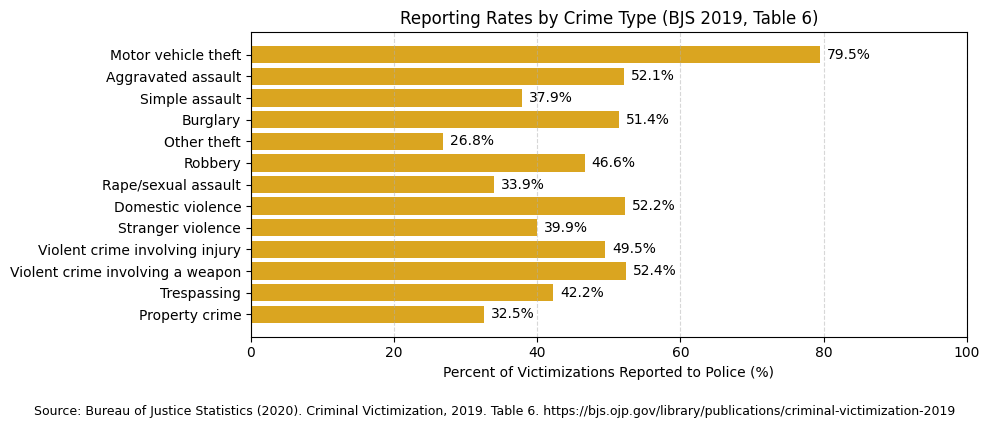

In [32]:
categories = list(bjs_rates.keys())
values = [round(bjs_rates[cat]*100, 1) for cat in categories]

plt.figure(figsize=(10, 4))
bars = plt.barh(categories, values, color='goldenrod')
plt.xlabel('Percent of Victimizations Reported to Police (%)')
plt.title('Reporting Rates by Crime Type (BJS 2019, Table 6)')
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar, val in zip(bars, values):
    plt.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val}%', va='center')

plt.tight_layout()
plt.figtext(
    0.5, -0.05,
    'Source: Bureau of Justice Statistics (2020). Criminal Victimization, 2019. Table 6. '
    'https://bjs.ojp.gov/library/publications/criminal-victimization-2019',
    wrap=True, ha='center', fontsize=9
)

sns.set_context("notebook", font_scale=1.1)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

def set_min_figsize(width=10, height=4):
    plt.gcf().set_size_inches(max(width, plt.gcf().get_size_inches()[0]),
                              max(height, plt.gcf().get_size_inches()[1]))

save_title = f'ReportingRates_by_BJS_withCaption'
plt.savefig(f'{save_title}.png')
plt.savefig(f'{save_title}.eps', format='eps')
plt.show()



### Mapping our datasets crime-types to BJS categories

The Baltimore crime dataset includes homicide (n = 1,343) and arson (n = 475) which are not included in BJS report. BJS is based on National Crime Victimization Survey (NCVS). The NCVS gathers data by interviewing people age 12 and older in a household setting about crimes they or their household experienced. This survey does not include fatal crimes because the victim is not available, this explains the exclusion of homicides. The arson however is not included in that survey because it is mostly reported by insurance companies and third parties and that a lot of the times there's no specific victim when the property is a public one.
To handle these two cases:

**Homicide reporting:**
Since the body turns up eventually, homicide is considered a known crime to police. However, by setting the homicides' report rate to 99%, we leave out a one percent chance for the cases that might be miss-categorized as missing person case and the body is never discovered. 

**Arson reporting:**  
National datasets (e.g. ATF’s BATS and USFA/NFIRS) categorize arson by type, property, or intent—but do not estimate how many go unreported. Since it is a form of property crime we use BJS rate for property crime (32.5%) as a conservative proxy.


> Note: These two crime types constitute a marginal share of the dataset—together comprising less than 1.2% of incidents for which BJS-based reporting probabilities are available. Given that our objective is to approximate the general crime reporting probability for simulation purposes, excluding or conservatively estimating categories with limited prevalence and undefined survey-based rates aligns with standard methodological practice.

<!-- These two crime types represent a small proportion of total crimes in our dataset from 2019 onward — together accounting for less than 1.2% of all cases with Known BJS reporting rates. Since our objective is to approximate the general crime reporting probability for simulation purposes, the exclusion or conservative estimation of rare or unquantified categories is consistent with standard practice when grounding simulations in national survey-based metrics.

 -->

In [33]:
Crime_report_probs= {**bjs_rates,'Homicide': 0.99}

In [34]:
crime_map = {
    'AUTO THEFT': 'Motor vehicle theft',
    'AGG. ASSAULT': 'Aggravated assault',
    'COMMON ASSAULT': 'Simple assault',
    'BURGLARY': 'Burglary',
    'TRESPASSING': 'Trespassing',  
    'LARCENY': 'Other theft',
    'LARCENY FROM AUTO': 'Other theft',
    'ROBBERY': 'Robbery',
    'ROBBERY - COMMERCIAL': 'Robbery',
    'ROBBERY - CARJACKING': 'Robbery',
    'RAPE': 'Rape/sexual assault',
    'SHOOTING': 'Violent crime involving a weapon',
    'DOMESTIC VIOLENCE': 'Domestic violence',
    'HOMICIDE': 'Homicide',
    'ARSON': 'Property crime'
}


### Creating weighted reporting probability table


In [35]:
crime_counts = df_Crime[df_Crime['year'] >= 2019]['description'].value_counts()
display(crime_counts)

LARCENY                 33536
COMMON ASSAULT          32538
AGG. ASSAULT            21277
LARCENY FROM AUTO       17129
BURGLARY                16618
AUTO THEFT              13185
ROBBERY                 11862
SHOOTING                 2879
ROBBERY - CARJACKING     2183
ROBBERY - COMMERCIAL     1688
HOMICIDE                 1343
RAPE                     1087
ARSON                     475
Name: description, dtype: int64

In [36]:
crime_report_probability_df = crime_counts.rename_axis('Crime').reset_index(name='Crime Count')

crime_report_probability_df['Mapped Category'] = crime_report_probability_df['Crime'].map(crime_map)
crime_report_probability_df['Report Probability'] = crime_report_probability_df['Mapped Category'].map(Crime_report_probs)

crime_report_probability_df['Weighted Contribution'] = (
    crime_report_probability_df['Crime Count'] * crime_report_probability_df['Report Probability']
)

display(crime_report_probability_df)

,Crime,Crime Count,Mapped Category,Report Probability,Weighted Contribution
0,LARCENY,33536,Other theft,0.268,8987.648
1,COMMON ASSAULT,32538,Simple assault,0.379,12331.902
2,AGG. ASSAULT,21277,Aggravated assault,0.521,11085.317
3,LARCENY FROM AUTO,17129,Other theft,0.268,4590.572
4,BURGLARY,16618,Burglary,0.514,8541.652
5,AUTO THEFT,13185,Motor vehicle theft,0.795,10482.075
6,ROBBERY,11862,Robbery,0.466,5527.692
7,SHOOTING,2879,Violent crime involving a weapon,0.524,1508.596
8,ROBBERY - CARJACKING,2183,Robbery,0.466,1017.278
9,ROBBERY - COMMERCIAL,1688,Robbery,0.466,786.608


In [37]:
effective_categories_df = crime_report_probability_df[~crime_report_probability_df['Report Probability'].isna()]
display(effective_categories_df)
weighted_sum = effective_categories_df["Weighted Contribution"].sum()
total_count = effective_categories_df["Crime Count"].sum()

P_reported = weighted_sum.sum() / total_count if total_count > 0 else 0

effective_categories_df = effective_categories_df.set_index('Crime')
print(f"Estimated reporting probability: {P_reported:.2%}")

,Crime,Crime Count,Mapped Category,Report Probability,Weighted Contribution
0,LARCENY,33536,Other theft,0.268,8987.648
1,COMMON ASSAULT,32538,Simple assault,0.379,12331.902
2,AGG. ASSAULT,21277,Aggravated assault,0.521,11085.317
3,LARCENY FROM AUTO,17129,Other theft,0.268,4590.572
4,BURGLARY,16618,Burglary,0.514,8541.652
5,AUTO THEFT,13185,Motor vehicle theft,0.795,10482.075
6,ROBBERY,11862,Robbery,0.466,5527.692
7,SHOOTING,2879,Violent crime involving a weapon,0.524,1508.596
8,ROBBERY - CARJACKING,2183,Robbery,0.466,1017.278
9,ROBBERY - COMMERCIAL,1688,Robbery,0.466,786.608


Estimated reporting probability: 42.82%


In [38]:
for crimeType in effective_categories_df.index:
    try:
        outdir = f'./Data Frames/Others/Reported/AllYears/{crimeType}/'
        os.makedirs(outdir)
    except FileExistsError:
        print(FileExistsError)

<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>
<class 'FileExistsError'>


In [39]:
print(effective_categories_df.loc["LARCENY", "Report Probability"])

0.268


In [40]:
# AllYears #########################################

for crimeType in effective_categories_df.index:
    print(crimeType)
    dfc = df_Crime[df_Crime['description'] == crimeType]
    Reported_rows = [] 

    p= [0.4, 0.428]#[0, effective_categories_df.loc[crimeType,'Report Probability']]
    for pRep in p:
        for crimeIndex, crimeRow in dfc.iterrows():
            temp = round(np.random.random(), 2)#Returns random floats in the half-open interval [0.0, 1.0)

            if temp < pRep:
                Reported_rows.append(crimeRow.to_dict())

        Reported = pd.DataFrame(Reported_rows, columns=dfc.columns)

        Reported.to_csv(f'Data Frames/Others/Reported/AllYears/{crimeType}/pReport-{str(pRep)}.csv', index=False)

        Reported_rows.clear()


LARCENY
COMMON ASSAULT
AGG. ASSAULT
LARCENY FROM AUTO
BURGLARY
AUTO THEFT
ROBBERY
SHOOTING
ROBBERY - CARJACKING
ROBBERY - COMMERCIAL
HOMICIDE
RAPE
ARSON
